In [114]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms.v2 as v2
import timm
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from pathlib import Path

In [115]:
train_dir = Path("data/fgvc-aircraft-2013b/data/images")
train_widths = []
train_heights = []

for img_path in train_dir.glob("*.jpg"):
    with Image.open(img_path) as img:
        w, h = img.size
        train_widths.append(w)
        train_heights.append(h)

<bound method Figure.tight_layout of <Figure size 640x480 with 1 Axes>>

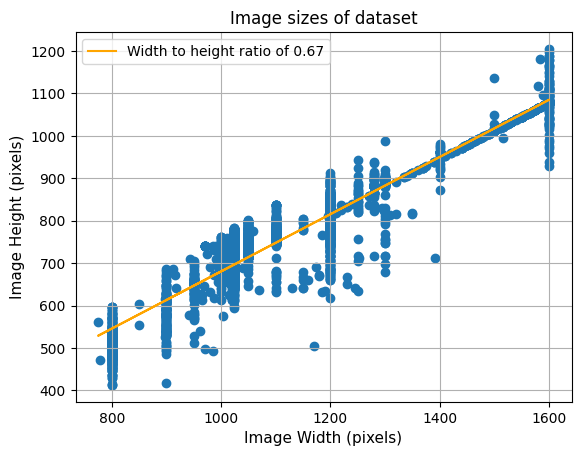

In [116]:
m,c=np.polyfit(np.array(train_widths), np.array(train_heights), deg=1)
# Visualisation of dataset:
fig_1, ax = plt.subplots()
ax.scatter(train_widths, train_heights)
ax.plot(np.array(train_widths), m*np.array(train_widths) + c, color='orange', ls="-", label=f"Width to height ratio of {m:.2f}")
ax.set_xlabel('Image Width (pixels)', fontsize=11)
ax.set_ylabel('Image Height (pixels)', fontsize=11)
ax.set_title('Image sizes of dataset')
ax.grid(True)
ax.legend()
fig_1.tight_layout

In [ ]:
model_dir = 'convnextv2_tiny.fcmae_ft_in22k_in1k'
image_size = 224
num_aircraft_variants = 100

temp_model = timm.create_model(model_dir,
    pretrained=True,
    num_classes=num_aircraft_variants,
    drop_path_rate=0.1) #temp model
data_config = timm.data.resolve_model_data_config(model)

In [118]:
train_transforms = v2.Compose([
    v2.Resize(size=[image_size,image_size]),
    v2.Pad(padding=0, padding_mode='edge'),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize(
        mean=data_config['mean'],
        std=data_config['std']
    )
])

val_transforms = v2.Compose([
    v2.Resize(size=[image_size,image_size]),
    v2.Pad(padding=0, padding_mode='edge'),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=data_config['mean'], std=data_config['std'])
])

#VERIFICATION OF MODEL SETUP
print(f"The model has loaded with {num_aircraft_variants} output classes, and target size of {image_size}X{image_size} ")

dataset_train = torchvision.datasets.FGVCAircraft(
    root='./data', 
    split='train', 
    download=True,
    annotation_level='variant',
    transform = train_transforms,
)

dataset_val = torchvision.datasets.FGVCAircraft(
    root='./data', 
    split='val', 
    download=True,
    annotation_level='variant',
    transform = val_transforms,
)

train_loader = DataLoader(dataset_train, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset_val, batch_size=16, shuffle=False, num_workers=0)

The model has loaded with 100 output classes, and target size of 224X224 


In [119]:
model = timm.create_model(
    model_dir,
    pretrained=True,
    num_classes=num_aircraft_variants
)

In [120]:
ds_fam = torchvision.datasets.FGVCAircraft(root='./data', split='train', annotation_level='family')
ds_manu = torchvision.datasets.FGVCAircraft(root='./data', split='train', annotation_level='manufacturer')

variant_to_family = {}
variant_to_manu = {}

for i in range(len(dataset_train)):
    variant_idx = dataset_train._labels[i]
    family_idx = ds_fam._labels[i]
    manu_idx = ds_manu._labels[i]

    variant_to_family[variant_idx] = family_idx
    variant_to_manu[variant_idx] = manu_idx

print(f"Training set: {len(dataset_train)} samples across {num_aircraft_variants} Variants.")
print(f"Validation set: {len(dataset_val)} samples.")
print(f"Hierarchical maps generated: 100 Variants -> {len(set(variant_to_family.values()))} Families -> {len(set(variant_to_manu.values()))} Manufacturers.")

Training set: 3334 samples across 100 Variants.
Validation set: 3333 samples.
Hierarchical maps generated: 100 Variants -> 70 Families -> 30 Manufacturers.


In [121]:
for param in model.parameters():
    param.requires_grad = True

In [122]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params}")
print(f"Trainable params: {trainable_params}")

Total params: 27943396
Trainable params: 27943396


In [123]:
criterion = torch.nn.CrossEntropyLoss()

backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if "head" in name or "fc" in name or "classifier" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimiser = optim.AdamW(
    [  
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params, "lr": 1e-4}
    ],
    weight_decay=1e-2
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=10, eta_min=1e-6)

In [125]:
num_epochs = 10

# Network training

for epoch in range(num_epochs):
    print(f"Epoch number {epoch+1} of {num_epochs}")
    model.train()

    running_loss=0.0
    correct_preds=0
    total_samples=0

    for batch_idx, (images,targets) in enumerate(train_loader):
        pred = model(images)
        loss = criterion(pred,targets)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        running_loss += loss.item() * images.size(0)
        preds = pred.argmax(dim=1)
        correct_preds += (preds == targets).sum().item()
        total_samples += targets.size(0)

    scheduler.step()

    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_preds / total_samples) * 100
    print(f"Epoch {epoch+1}: Training loss of {epoch_loss:.4f} | Training accuracy of {epoch_acc:.2f}")

print("Training complete")

Epoch number 1 of 10
Epoch 1: Training loss of 3.3547 | Training accuracy of 22.23
Epoch number 2 of 10


KeyboardInterrupt: 

In [112]:
#validation testing
model.eval()

variant_correct = 0
family_correct = 0
manu_correct = 0
total_val_samples = 0

v2f_tensor = torch.tensor([variant_to_family[i] for i in range(len(variant_to_family))])
v2m_tensor = torch.tensor([variant_to_manu[i] for i in range(len(variant_to_manu))])

with torch.no_grad():
    for images, targets in val_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        variant_correct += (preds == targets).sum().item()

        pred_fam = v2f_tensor[preds]
        true_fam = v2f_tensor[targets]
        family_correct += (pred_fam == true_fam).sum().item()

        pred_manu = v2m_tensor[preds]
        true_manu = v2m_tensor[targets]
        manu_correct += (pred_manu == true_manu).sum().item()

        total_val_samples += targets.size(0)

variant_acc = (variant_correct/total_val_samples) * 100
family_acc = (family_correct/total_val_samples) * 100
manu_acc = (manu_correct/total_val_samples) * 100

print("Validation testing:")
print(f"Variant accuracy: {variant_acc:.2f}%")
print(f"Family accuracy: {family_acc:.2f}%")
print(f"Manufacturer accuracy: {manu_acc:.2f}%")

Validation testing:
Variant accuracy: 34.38%
Family accuracy: 44.28%
Manufacturer accuracy: 56.74%
